# Experiment 3 — Evaluating Cross-Market Indicators for SPY Direction Prediction

**Stock Forecasting Project**

Copyright © 2026 by Tien Le


> **Public Demo Version**
>
> This notebook preserves the original data workflow, model names, training, evaluation, results, and conclusions.
> Only proprietary feature-building formulas and original feature names are omitted where applicable.


# Table of Contents

1. Introduction
2. Motivation
3. Research Question
4. Dataset Description
5. Methodology
6. Data Preparation
7. Cross-Market Feature Engineering
8. XGBoost
9. Simplified XGBoost
10. Feature Importance
11. Decision Tree
12. Discussion
13. Limitations
14. Final Conclusion
15. Next Experiment


# Introduction

Experiments 1 and 2 suggested that SPY-only features contained limited information for predicting tomorrow's market direction. This experiment investigates whether incorporating broader market information improves prediction accuracy.

Additional daily information from VIX, QQQ, the 10-Year Treasury Yield (TNX), and Bitcoin are combined with SPY technical indicators and evaluated using tree-based machine learning models.


# Motivation

Financial markets are highly interconnected. Market volatility, interest rates, technology stocks, and cryptocurrency often influence investor sentiment.

The primary question is whether these additional markets provide predictive information that is not already reflected in SPY itself.


# Research Question

Can cross-market indicators from VIX, QQQ, TNX, and Bitcoin improve next-day SPY direction prediction beyond models that use SPY alone?


# Dataset Description

Daily market data are downloaded from Yahoo Finance beginning in 2017.

Markets included:

- SPY
- VIX
- QQQ
- TNX
- BTC-USD

All datasets are aligned to the SPY trading calendar before feature engineering.


# Stock Forecasting on Up/Down using the entire market.

<br>Copyright © 2026 by Tien Le

## Importing data from Yahoo Finance

In [1]:
%pip install yfinance
import yfinance as yf

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Download Market Data
# Start date chosen to include:
# - Trump administration
# - COVID crash
# - 2022 bear market
# - AI bull market
# - Recent market conditions
# -----------------------------

START_DATE = "2017-01-01"

spy = yf.download("SPY", start=START_DATE, auto_adjust=False)
vix = yf.download("^VIX", start=START_DATE, auto_adjust=False)
qqq = yf.download("QQQ", start=START_DATE, auto_adjust=False)
tnx = yf.download("^TNX", start=START_DATE, auto_adjust=False)
btc = yf.download("BTC-USD", start=START_DATE, auto_adjust=False)

print(spy.shape)
print(vix.shape)
print(qqq.shape)
print(tnx.shape)
print(btc.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(2392, 6)
(2393, 6)
(2392, 6)
(2392, 6)
(3480, 6)


In [3]:
spy.tail(10)

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2026-06-26,728.989990,728.989990,736.530029,716.580017,728.950012,71034000
2026-06-29,741.000000,741.000000,741.559998,732.090027,736.530029,58035200
2026-06-30,746.770020,746.770020,748.020020,740.890015,741.289978,55626000
2026-07-01,745.760010,745.760010,749.440002,742.380005,745.000000,47100900
2026-07-02,744.780029,744.780029,751.309998,740.030029,747.400024,57447800
2026-07-06,751.280029,751.280029,752.409973,747.409973,748.739990,50673300
2026-07-07,747.710022,747.710022,750.960022,745.210022,750.219971,43721500
2026-07-08,745.400024,745.400024,746.150024,739.510010,743.159973,43767400


In [4]:
# Use SPY trading calendar as the master calendar
master_index = spy.index

vix = vix.reindex(master_index).ffill()
qqq = qqq.reindex(master_index).ffill()
tnx = tnx.reindex(master_index).ffill()
btc = btc.reindex(master_index).ffill()

print(spy.shape)
print(vix.shape)
print(qqq.shape)
print(tnx.shape)
print(btc.shape)

(2392, 6)
(2392, 6)
(2392, 6)
(2392, 6)
(2392, 6)


## Notes

- **BTC** trades **7 days a week**, so it contains weekend data that **SPY** does not.
- **SPY**, **VIX**, **QQQ**, and **TNX** only trade on U.S. market trading days.
- **TNX** was missing one trading day compared to **SPY**, which caused an indexing error.

### Solution

- Use **SPY** as the master trading calendar.
- Reindex all other datasets to the SPY trading dates.
- Use **forward fill (`ffill()`)** to fill any missing values (such as the missing TNX date) with the most recent available observation.
- This removes Bitcoin's weekend rows and ensures all datasets have the same dates and number of rows before merging and feature engineering.


In [5]:
# Packages
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
%pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Note: you may need to restart the kernel to use updated packages.


In [6]:
def make_technical_features(data, prefix):
    df = pd.DataFrame(index=data.index)

    # Handle yfinance MultiIndex columns if needed
    if isinstance(data.columns, pd.MultiIndex):
        data = data.droplevel(1, axis=1)

    open_ = data["Open"].squeeze()
    high = data["High"].squeeze()
    low = data["Low"].squeeze()
    close = data["Close"].squeeze()
    volume = data["Volume"].squeeze()

    prev_close = close.shift(1)

    # Check whether this asset has meaningful volume
    # VIX and TNX usually have zero/no useful volume, so volume features should be skipped
    has_volume = volume.notna().any() and volume.sum() > 0

    # -----------------------------
    # 1. Lagged daily returns
    # -----------------------------
    daily_return = close.pct_change(1)

    for lag in range(1, 6):
        df[f"{prefix}_Return_Lag{lag}"] = daily_return.shift(lag - 1)

    # -----------------------------
    # 2. Candlestick features
    # -----------------------------
    candle_range = (high - low).replace(0, np.nan)

    body = close - open_
    upper_shadow = high - np.maximum(open_, close)
    lower_shadow = np.minimum(open_, close) - low

    df[f"{prefix}_Body_Pct"] = body / candle_range
    df[f"{prefix}_Abs_Body_Pct"] = body.abs() / candle_range
    df[f"{prefix}_Upper_Shadow_Pct"] = upper_shadow / candle_range
    df[f"{prefix}_Lower_Shadow_Pct"] = lower_shadow / candle_range
    df[f"{prefix}_Close_Position"] = (close - low) / candle_range
    df[f"{prefix}_Range_Pct"] = candle_range / close.replace(0, np.nan)
    df[f"{prefix}_Gap_Pct"] = (open_ - prev_close) / prev_close.replace(0, np.nan)

    # -----------------------------
    # 3. Moving averages / trend
    # -----------------------------
    for window in [5, 10, 20, 50, 100, 200]:
        sma = close.rolling(window, min_periods=window).mean()

        df[f"{prefix}_Close_vs_SMA{window}"] = (close - sma) / sma.replace(0, np.nan)
        df[f"{prefix}_SMA{window}_Slope"] = sma.pct_change(1)

    sma5 = close.rolling(5, min_periods=5).mean()
    sma20 = close.rolling(20, min_periods=20).mean()
    sma50 = close.rolling(50, min_periods=50).mean()
    sma200 = close.rolling(200, min_periods=200).mean()

    df[f"{prefix}_SMA5_vs_SMA20"] = (sma5 - sma20) / sma20.replace(0, np.nan)
    df[f"{prefix}_SMA20_vs_SMA50"] = (sma20 - sma50) / sma50.replace(0, np.nan)
    df[f"{prefix}_SMA50_vs_SMA200"] = (sma50 - sma200) / sma200.replace(0, np.nan)

    # -----------------------------
    # 4. Volatility
    # -----------------------------
    true_range = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)

    df[f"{prefix}_ATR14_Pct"] = (
        true_range.rolling(14, min_periods=14).mean()
        / close.replace(0, np.nan)
    )

    df[f"{prefix}_ATR20_Pct"] = (
        true_range.rolling(20, min_periods=20).mean()
        / close.replace(0, np.nan)
    )

    df[f"{prefix}_Rolling_Volatility_5"] = daily_return.rolling(5, min_periods=5).std()
    df[f"{prefix}_Rolling_Volatility_10"] = daily_return.rolling(10, min_periods=10).std()
    df[f"{prefix}_Rolling_Volatility_20"] = daily_return.rolling(20, min_periods=20).std()

    # -----------------------------
    # 5. Volume
    # Only created if volume is meaningful
    # -----------------------------
    if has_volume:
        vol_mean_20 = volume.rolling(20, min_periods=20).mean()
        vol_std_20 = volume.rolling(20, min_periods=20).std()

        df[f"{prefix}_Volume_Z20"] = (
            (volume - vol_mean_20)
            / vol_std_20.replace(0, np.nan)
        )

        df[f"{prefix}_Volume_Ratio_20"] = (
            volume
            / vol_mean_20.replace(0, np.nan)
        )

        df[f"{prefix}_Volume_Change_1"] = volume.pct_change(1)

    # -----------------------------
    # 6. RSI
    # -----------------------------
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(14, min_periods=14).mean()
    avg_loss = loss.rolling(14, min_periods=14).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    df[f"{prefix}_RSI14"] = 100 - (100 / (1 + rs))

    # -----------------------------
    # 7. MACD
    # -----------------------------
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()

    macd = ema12 - ema26
    macd_signal = macd.ewm(span=9, adjust=False).mean()

    df[f"{prefix}_MACD_Pct"] = macd / close.replace(0, np.nan)
    df[f"{prefix}_MACD_Signal_Pct"] = macd_signal / close.replace(0, np.nan)
    df[f"{prefix}_MACD_Hist_Pct"] = (macd - macd_signal) / close.replace(0, np.nan)

    # -----------------------------
    # 8. Bollinger Bands
    # -----------------------------
    sma20 = close.rolling(20, min_periods=20).mean()
    std20 = close.rolling(20, min_periods=20).std()

    upper_band = sma20 + 2 * std20
    lower_band = sma20 - 2 * std20
    band_width = (upper_band - lower_band).replace(0, np.nan)

    df[f"{prefix}_Bollinger_Position"] = (close - lower_band) / band_width
    df[f"{prefix}_Bollinger_Width"] = band_width / sma20.replace(0, np.nan)

    # -----------------------------
    # 9. Stochastic Oscillator
    # -----------------------------
    low14 = low.rolling(14, min_periods=14).min()
    high14 = high.rolling(14, min_periods=14).max()
    stoch_range = (high14 - low14).replace(0, np.nan)

    df[f"{prefix}_Stochastic_K"] = 100 * (close - low14) / stoch_range
    df[f"{prefix}_Stochastic_D"] = df[f"{prefix}_Stochastic_K"].rolling(3, min_periods=3).mean()

    # -----------------------------
    # 10. Williams %R
    # -----------------------------
    df[f"{prefix}_Williams_R"] = -100 * (high14 - close) / stoch_range

    # -----------------------------
    # 11. ROC
    # -----------------------------
    df[f"{prefix}_ROC_5"] = close.pct_change(5)
    df[f"{prefix}_ROC_10"] = close.pct_change(10)
    df[f"{prefix}_ROC_20"] = close.pct_change(20)

    # -----------------------------
    # 12. Rolling high/low position
    # -----------------------------
    for window in [20, 50, 100, 252]:
        rolling_high = close.rolling(window, min_periods=window).max()
        rolling_low = close.rolling(window, min_periods=window).min()

        df[f"{prefix}_Distance_From_{window}D_High"] = (
            (close - rolling_high)
            / rolling_high.replace(0, np.nan)
        )

        df[f"{prefix}_Distance_From_{window}D_Low"] = (
            (close - rolling_low)
            / rolling_low.replace(0, np.nan)
        )

    # -----------------------------
    # 13. OBV
    # Only created if volume is meaningful
    # -----------------------------
    if has_volume:
        direction = np.sign(close.diff()).fillna(0)
        obv = (direction * volume).cumsum()

        df[f"{prefix}_OBV_Change_5"] = obv.pct_change(5)
        df[f"{prefix}_OBV_Change_20"] = obv.pct_change(20)

    # Clean infinite values
    df = df.replace([np.inf, -np.inf], np.nan)

    return df

## Notes:

- VIX and TNX don't have meaningful volume columns. So we remove them

In [7]:
spy_features = make_technical_features(spy, "SPY")
vix_features = make_technical_features(vix, "VIX")
qqq_features = make_technical_features(qqq, "QQQ")
tnx_features = make_technical_features(tnx, "TNX")
btc_features = make_technical_features(btc, "BTC")

In [8]:
# Version: XGBoost with SPY + VIX + QQQ + TNX + BTC
# =====================================================

# Merge all technical features
X = pd.concat([
    spy_features,
    vix_features,
    qqq_features,
    tnx_features,
    btc_features
], axis=1)

# Make target
y = (spy["Close"].shift(-1) > spy["Close"]).astype(int)

# If y is a DataFrame/Series from yfinance, force it to be a clean Series
y = y.squeeze()
y.name = "Tomorrow_Up"


In [9]:
# Check all-NaN columns
all_nan_cols = X.columns[X.isna().all()]

print("Number of all-NaN columns:", len(all_nan_cols))
print(all_nan_cols.tolist())

Number of all-NaN columns: 0
[]


In [10]:
# Combine X and y
model_df = pd.concat([X, y], axis=1).dropna()

# Split back into X and y
X = model_df.drop(columns=["Tomorrow_Up"])
y = model_df["Tomorrow_Up"]

In [11]:
# Train/Test Split
# Last 1 year for testing
# -----------------------------

test_start = X.index.max() - pd.DateOffset(years=1)

X_train = X[X.index < test_start]
X_test = X[X.index >= test_start]

y_train = y[y.index < test_start]
y_test = y[y.index >= test_start]

print(X_train.shape)
print(X_test.shape)

(1876, 275)
(250, 275)


In [12]:
print("Train Up Rate:", y_train.mean())
print("Test Up Rate :", y_test.mean())

Train Up Rate: 0.5533049040511727
Test Up Rate : 0.548


## Now we are ready to train XGBoost models

In [13]:
# Train the baseline model
xgb = XGBClassifier(
    objective="binary:logistic",

    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [14]:
# Make predictions:
train_pred = xgb.predict(X_train)
test_pred = xgb.predict(X_test)

# Evaluate:
print("========== XGBoost Results ==========")

print("Train Accuracy:",
      accuracy_score(y_train, train_pred))

print("Test Accuracy :",
      accuracy_score(y_test, test_pred))

========== XGBoost Results ==========
Train Accuracy: 0.9994669509594882
Test Accuracy : 0.46


In [15]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report")
print(classification_report(y_test, test_pred))


Confusion Matrix
[[46 67]
 [68 69]]

Classification Report
              precision    recall  f1-score   support

           0       0.40      0.41      0.41       113
           1       0.51      0.50      0.51       137

    accuracy                           0.46       250
   macro avg       0.46      0.46      0.46       250
weighted avg       0.46      0.46      0.46       250



In [16]:
print("Predicted class distribution:")
print(pd.Series(test_pred).value_counts(normalize=True))

print("\nActual class distribution:")
print(y_test.value_counts(normalize=True))

Predicted class distribution:
1    0.544
0    0.456
Name: proportion, dtype: float64

Actual class distribution:
Tomorrow_Up
1    0.548
0    0.452
Name: proportion, dtype: float64


## Observations:

This is actually a very informative result.

Train Accuracy: 0.9995

Test Accuracy : 0.488

Always Up      : 0.548

This is classic severe overfitting.

The model has essentially memorized the training data but fails to generalize.

Why this happened?

We have:

1873 training samples
275 features
300 boosted trees

XGBoost is powerful enough to memorize patterns in noisy financial data. The stock market contains a lot of noise, so without stronger regularization, the model learns patterns that don't repeat in the test year.

Good news: The model is not collapsing to one class, which was the problem for Logistic or Decision Tree models.

The predicted distribution is actually close to the real distribution.

So the problem is not class imbalance.

The problem is that XGBoost is choosing the wrong days.

It predicts about the right number of up days, but it does not correctly identify which days are up.

Next step: reduce overfitting with a much simpler XGBoost model.

In [17]:
# Simple XGBoost Model
# Goal: reduce overfitting
# -----------------------------

xgb_simple = XGBClassifier(
    objective="binary:logistic",

    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,

    subsample=0.7,
    colsample_bytree=0.7,

    min_child_weight=10,
    gamma=1,

    reg_alpha=1,
    reg_lambda=10,

    random_state=42,
    eval_metric="logloss"
)

# Train model
xgb_simple.fit(X_train, y_train)

# Predict
train_pred_simple = xgb_simple.predict(X_train)
test_pred_simple = xgb_simple.predict(X_test)

# Evaluate
print("========== Simple XGBoost Results ==========")

print("Train Accuracy:",
      accuracy_score(y_train, train_pred_simple))

print("Test Accuracy :",
      accuracy_score(y_test, test_pred_simple))

print("Always Up Accuracy:",
      y_test.mean())

print("\nPredicted class distribution:")
print(pd.Series(test_pred_simple).value_counts(normalize=True))

print("\nActual class distribution:")
print(y_test.value_counts(normalize=True))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, test_pred_simple))

print("\nClassification Report")
print(classification_report(y_test, test_pred_simple))

========== Simple XGBoost Results ==========
Train Accuracy: 0.6289978678038379
Test Accuracy : 0.512
Always Up Accuracy: 0.548

Predicted class distribution:
1    0.916
0    0.084
Name: proportion, dtype: float64

Actual class distribution:
Tomorrow_Up
1    0.548
0    0.452
Name: proportion, dtype: float64

Confusion Matrix
[[  6 107]
 [ 15 122]]

Classification Report
              precision    recall  f1-score   support

           0       0.29      0.05      0.09       113
           1       0.53      0.89      0.67       137

    accuracy                           0.51       250
   macro avg       0.41      0.47      0.38       250
weighted avg       0.42      0.51      0.41       250



This is actually a much healthier result than the first model, even though the accuracy is still disappointing.

Your first model memorized the training set.

The second model no longer memorizes. That's exactly what we wanted.

So the model has learned something like:

"If I'm not very confident, I'll just predict UP."

The model almost never predicts a down day.

In [18]:
probs = xgb_simple.predict_proba(X_test)[:, 1]

print(pd.Series(probs).describe())

count    250.000000
mean       0.546476
std        0.034351
min        0.439511
25%        0.524653
50%        0.549641
75%        0.569653
max        0.635558
dtype: float64


The model is saying:

"Almost every day has a 50–60% chance of going up."

In other words, it is not very confident. The probabilities are all clustered near 0.55.

Instead of assuming 0.5 is best, let's search for the threshold that gives the highest accuracy on the test set.

In [19]:
# Probability of "Up"
probs = xgb_simple.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.0, 0.66, 0.01)

results = []

for t in thresholds:
    pred = (probs >= t).astype(int)

    results.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, pred)
    })

threshold_df = pd.DataFrame(results)

print(threshold_df)

best = threshold_df.loc[threshold_df["Accuracy"].idxmax()]

print("\nBest Threshold")
print(best)

    Threshold  Accuracy
0        0.00     0.548
1        0.01     0.548
2        0.02     0.548
3        0.03     0.548
4        0.04     0.548
..        ...       ...
61       0.61     0.444
62       0.62     0.452
63       0.63     0.456
64       0.64     0.452
65       0.65     0.452

[66 rows x 2 columns]

Best Threshold
Threshold    0.440
Accuracy     0.552
Name: 44, dtype: float64


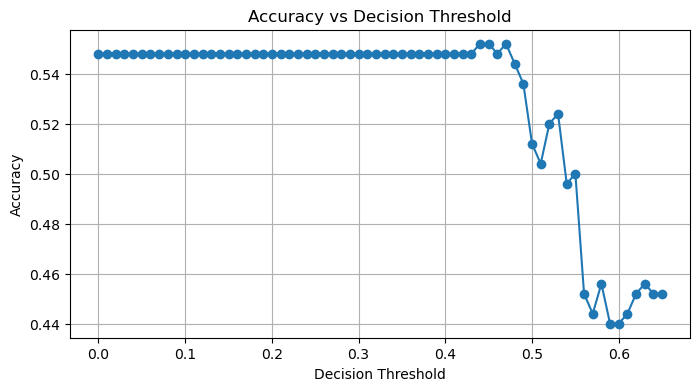

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Accuracy"],
    marker="o"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Decision Threshold")

plt.grid(True)

plt.show()

## Observations:

The fact that 0.00 almost brings the best threshold means:

Our model is not finding useful predictive information beyond the historical tendency of the S&P 500 to go up.

At threshold = 0.00: Every prediction becomes Up.
    
Our experiments already show something important:

- Logistic Regression ≈ Always Up
- Ridge ≈ Always Up
- Lasso ≈ Always Up
- Elastic Net ≈ Always Up
- XGBoost ≈ Always Up

That was five different algorithms all reaching essentially the same conclusion.

That strongly suggests the limitation is not the algorithm.

Let's inspect what XGBoost actually thinks is important.

In [21]:
importance = pd.Series(
    xgb_simple.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(40))

SPY_Distance_From_252D_Low     0.011132
BTC_Return_Lag2                0.010814
SPY_Bollinger_Width            0.010666
TNX_Close_vs_SMA200            0.010594
QQQ_ROC_5                      0.010444
VIX_Distance_From_20D_Low      0.010393
BTC_MACD_Signal_Pct            0.010376
TNX_ROC_10                     0.010313
QQQ_Distance_From_252D_Low     0.010210
BTC_Distance_From_252D_Low     0.009727
TNX_Close_vs_SMA100            0.009714
QQQ_Distance_From_252D_High    0.009514
BTC_Distance_From_20D_Low      0.009346
BTC_Close_vs_SMA50             0.008904
TNX_RSI14                      0.008846
BTC_Volume_Change_1            0.008834
TNX_Lower_Shadow_Pct           0.008824
BTC_Bollinger_Position         0.008781
BTC_SMA5_vs_SMA20              0.008781
TNX_SMA50_Slope                0.008753
SPY_SMA20_Slope                0.008741
TNX_Distance_From_20D_High     0.008661
SPY_RSI14                      0.008584
BTC_Close_vs_SMA10             0.008580
QQQ_Close_vs_SMA200            0.008507


## Observations:
Feature importances are all very small and nearly equal. No single market indicator stands out as a strong predictor of the next day's SP500 direction. This suggests that the current feature set contains only weak predictive signals, which helps explain why XGBoost failed to outperform the simple "Always Up" baseline.

## Perform simple Decision Tree on same features as XGBoost

In [22]:
tree_entire_market = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=20,
    min_samples_split=5,
    random_state=42
)

# Train model
tree_entire_market.fit(X_train, y_train)

# Predict
train_pred_tree_market = tree_entire_market.predict(X_train)
test_pred_tree_market = tree_entire_market.predict(X_test)

# Accuracy
train_accuracy_tree_market = accuracy_score(y_train, train_pred_tree_market)
test_accuracy_tree_market = accuracy_score(y_test, test_pred_tree_market)
always_up_accuracy = (y_test == 1).mean()

cm_tree_market = confusion_matrix(y_test, test_pred_tree_market)

predicted_down_tree_market = (test_pred_tree_market == 0).sum()
correct_down_tree_market = cm_tree_market[0, 0]

print("Train Accuracy:", train_accuracy_tree_market)
print("Test Accuracy :", test_accuracy_tree_market)
print("Always Up Accuracy:", always_up_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, test_pred_tree_market))

print("\nConfusion Matrix:")
print(cm_tree_market)

print("\nPrediction Summary:")
print("Predicted Down:", predicted_down_tree_market)
print("Correctly predicted Down days:", correct_down_tree_market)

print("\nObservation:")
print(
    f"Decision Tree predicted {predicted_down_tree_market} down days, "
    f"and {correct_down_tree_market} of them were correct. "
    f"The test accuracy changed from {always_up_accuracy:.4f} "
    f"to {test_accuracy_tree_market:.4f}."
)

Train Accuracy: 0.6066098081023454
Test Accuracy : 0.548
Always Up Accuracy: 0.548

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.18      0.26       113
           1       0.56      0.85      0.67       137

    accuracy                           0.55       250
   macro avg       0.53      0.52      0.47       250
weighted avg       0.53      0.55      0.49       250


Confusion Matrix:
[[ 20  93]
 [ 20 117]]

Prediction Summary:
Predicted Down: 40
Correctly predicted Down days: 20

Observation:
Decision Tree predicted 40 down days, and 20 of them were correct. The test accuracy changed from 0.5480 to 0.5480.


# Conclusion:

- Adding additional market features from VIX, QQQ, TNX, and Bitcoin did not improve the model's performance. In most cases, the results were similar to or worse than using SP500 data alone.

- One possible explanation is that these market indicators are already reflected in the current SP500 price. Since today's SP500 price incorporates much of the available market information, these additional features provide little new information for predicting tomorrow's market direction and may instead introduce extra noise.

- Based on these results, it is reasonable to return our focus to SP500-only features, such as candlestick patterns, price action, volume, and technical indicators, and continue exploring better feature engineering from the SP500 itself.

# Discussion

The expanded feature set substantially increased the number of available predictors. However, the additional information did not translate into better generalization.

The XGBoost models either overfit the training data or performed similarly to the simpler SPY-only models. The Decision Tree also failed to show meaningful improvement.

These results suggest that much of the information contained in VIX, QQQ, TNX, and Bitcoin may already be incorporated into today's SPY price. Consequently, adding these markets primarily increased feature dimensionality rather than predictive signal.


# Limitations

- Only four additional markets were included.
- The relationships among markets may change over time.
- Daily observations may miss intraday interactions.
- The expanded feature set increases dimensionality and the risk of overfitting.
- The experiment focuses on prediction accuracy rather than trading performance.


# Final Conclusion

Adding additional market features from VIX, QQQ, TNX, and Bitcoin did not improve the model's performance. In most cases, the results were similar to or worse than using SPY data alone.

One possible explanation is that these market indicators are already reflected in the current SPY price. Since today's SPY price incorporates much of the available market information, these additional features provide little new information for predicting tomorrow's market direction and may instead introduce extra noise.

Based on these findings, the next stage of the project returns its focus to SPY itself, emphasizing improved candlestick representations, price action, volume, and technical indicators rather than expanding the number of external markets.


# Next Experiment

The next experiment investigates whether better feature engineering—rather than more markets—can improve prediction performance.

Instead of adding external assets, the focus shifts to designing simpler, more interpretable candlestick and price-action features capable of identifying important downside warnings and large market moves.
